<a href="https://colab.research.google.com/github/JIGGISTYLE/handwritten/blob/main/handwritten.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#workflow to convert image into eq


Upload image

      ↓
Convert to grayscale

      ↓
Threshold (black/white)

      ↓
Find contours

      ↓
Segment characters

      ↓
Show detected characters


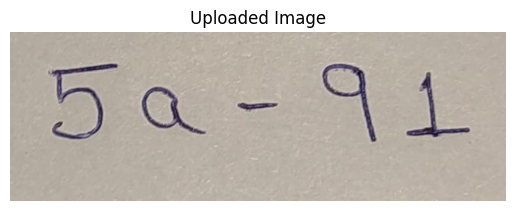

In [1]:
import cv2
import matplotlib.pyplot as plt

# load image
# img_path = "/content/drive/MyDrive/projects/equation_project/test_images/equation1.jpg"
image = cv2.imread("eq1.jpeg")

# convert BGR to RGB , because opencv user bgr as defaut and others as rgb
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()



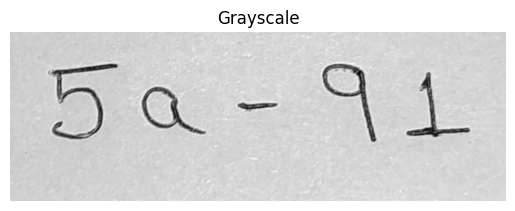

In [2]:
# covert to gray
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

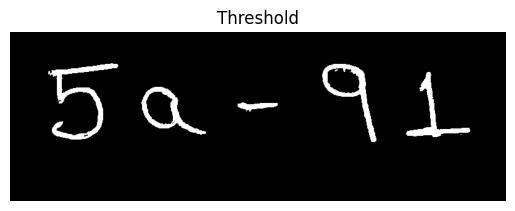

In [3]:
# covert to black and white / thrasholding image / binary image
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)  # cv2,threshold(gray_img, thresh, max_value , thresholding type) it returns rit(thresh , not important),thresh_img

plt.imshow(thresh, cmap="gray")
plt.title("Threshold")
plt.axis("off")
plt.show()

In [4]:
# detect charcchters or contours
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)


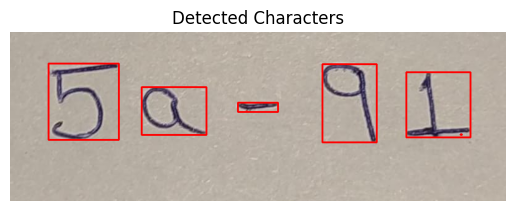

In [5]:
# bounding boxex . visulaizezs the detected charchteds
import numpy as np

image_copy = image.copy()

boxes = []

for cnt in contours:

    x,y,w,h = cv2.boundingRect(cnt)

    if w*h > 100:  # to remove dust or very small contures

      boxes.append((x,y,w,h))

    cv2.rectangle(image_copy,(x,y),(x+w,y+h),(255,0,0),2)

plt.imshow(image_copy)
plt.title("Detected Characters")
plt.axis("off")
plt.show()


In [6]:
# sort boxes
boxes = sorted(boxes, key=lambda a: a[0])  # from left to right , sort x coordinate wise ,  a varible is a[0] of (x,y,w,h)
boxes

[(62, 52, 114, 123),
 (213, 90, 105, 77),
 (369, 115, 65, 15),
 (506, 53, 88, 126),
 (642, 66, 104, 105)]

In [7]:
#crop each charchter
characters = []

for (x, y, w, h) in boxes:
    char = thresh[y:y+h, x:x+w]   # numpy slicing its image[row,colomn] not image[x,y], crop from threshold image , from y to y+height , and x to x+width
    characters.append(char)


In [8]:
#resize
resized_chars = []

for char in characters:
    char = cv2.resize(char, (28, 28))
    resized_chars.append(char)



In [9]:
# normalize for cnn
normalized_chars = []

for char in resized_chars:
    char = char / 255.0
    normalized_chars.append(char)


In [10]:
# convert to tensors
import torch

tensor_chars = []

for char in normalized_chars:
    char = np.array(char, dtype=np.float32)
    char = np.expand_dims(char, axis=0)   # add channel dim → (1,28,28)
    char = torch.tensor(char)
    tensor_chars.append(char)



In [11]:
# make batches
input_batch = torch.stack(tensor_chars)
input_batch.size()

torch.Size([5, 1, 28, 28])

In [12]:

# pip install torch torchvision

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [14]:
# cnnmodel
class CharCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # [N,32,14,14]
        x = self.pool(F.relu(self.conv2(x)))   # [N,64,7,7]

        x = x.view(x.size(0), -1)              # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [15]:
labels = ['0','1','2','3','4','5','6','7','8','9','+','-','*','/','=','x','y']

In [16]:
num_classes = len(labels)

In [17]:
model = CharCNN(num_classes)
model.eval()

CharCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=17, bias=True)
)

now we will make , make the model from dataset to final prediction

use triple ` for structures

```
MyDrive/
└── equation_project/
    └── dataset/
        ├── train/
        │   ├── 0/
        │   ├── 1/
        │   ├── 2/
        │   ├── ...
        │   ├── plus/
        │   ├── minus/
        │   ├── multiply/
        │   ├── divide/
        │   ├── equal/
        │   ├── x/
        │   └── y/
        │
        └── test/
            ├── 0/
            ├── 1/
            ├── ...
            ├── plus/
            ├── minus/
            ├── multiply/
            ├── divide/
            ├── equal/
            ├── x/
            └── y/
```

In [18]:
# !git add .
# !git commit -m "Daily update"
# !git push

In [19]:
# organize collab

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
# import os

# project_path = "/content/drive/MyDrive/projects/equation_project"
# os.makedirs(project_path, exist_ok=True)

# print("Project folder ready")

In [22]:
# base = "/content/drive/MyDrive/projects/equation_project/dataset"

# splits = ["train", "test"]
# classes = ['0','1','2','3','4','5','6','7','8','9',
#            'plus','minus','multiply','divide','equal',
#            'x','y','a','b']

# for split in splits:
#     for cls in classes:
#         os.makedirs(f"{base}/{split}/{cls}", exist_ok=True)

# print("Dataset folders created")

In [23]:
# # start downloading
# import os
# import cv2
# from torchvision import datasets

In [24]:
# mnist_train = datasets.MNIST(root="/content/data", train=True, download=True)
# mnist_test  = datasets.MNIST(root="/content/data", train=False, download=True)

In [25]:
# base = "/content/drive/MyDrive/projects/equation_project/dataset"

In [26]:
# import numpy as np
# import cv2

# def save_mnist_fast(dataset, split, limit_per_class):
#     counts = {str(i): 0 for i in range(10)}

#     for img, label in dataset:
#         cls = str(label)

#         if counts[cls] >= limit_per_class:
#             continue

#         img = np.array(img)
#         path = f"{base}/{split}/{cls}/{counts[cls]}.png"
#         cv2.imwrite(path, img)

#         counts[cls] += 1

#         if all(v >= limit_per_class for v in counts.values()):
#             break

#     print(f"{split} saved")

In [27]:
# save_mnist_fast(mnist_test, "test", 500)


In [28]:
base = "/content/drive/MyDrive/projects/equation_project/dataset"


In [29]:
import os

train_path = base +"/train"

for cls in sorted(os.listdir(train_path)):
    cls_path = os.path.join(train_path, cls)
    print(cls, "→", len(os.listdir(cls_path)))

0 → 2360
1 → 2668
2 → 2327
3 → 2469
4 → 2342
5 → 2132
6 → 2345
7 → 2453
8 → 2287
9 → 2387
a → 5937
b → 5967
divide → 268
equal → 0
minus → 140
multiply → 1207
plus → 136
x → 7795
y → 7762


In [30]:
import os

test_path = base +"/test"

for cls in sorted(os.listdir(test_path)):
    cls_path = os.path.join(test_path, cls)
    print(cls, "→", len(os.listdir(cls_path)))

0 → 500
1 → 500
2 → 500
3 → 500
4 → 500
5 → 500
6 → 500
7 → 500
8 → 500
9 → 500
a → 800
b → 800
divide → 67
equal → 0
minus → 23
multiply → 302
plus → 18
x → 800
y → 800


In [31]:
# emnist for letter a b x y
# import torchvision
# from torchvision import datasets, transforms

In [32]:
# transform = transforms.Compose([
#     transforms.ToTensor()
# ])

In [33]:
# train_data = datasets.EMNIST(
#     root="emnist_data",
#     split="letters",
#     train=True,
#     download=True,
#     transform=transform
# )

# test_data = datasets.EMNIST(
#     root="emnist_data",
#     split="letters",
#     train=False,
#     download=True,
#     transform=transform
# )

100%|██████████| 562M/562M [00:02<00:00, 214MB/s]


In [34]:
# target = {
#     1: 'a',
#     2: 'b',
#     24: 'x',
#     25: 'y'
# }

In [35]:
# import os
# import numpy as np
# from PIL import Image

# base = "/content/drive/MyDrive/projects/equation_project/dataset"

# def save_emnist_fast(dataset, split):
#     labels = np.array(dataset.targets)

#     for lbl, ch in target.items():
#         folder = f"{base}/{split}/{ch}"
#         os.makedirs(folder, exist_ok=True)

#         idxs = np.where(labels == lbl)[0]   # only indices of that letter

#         for i, idx in enumerate(idxs):
#             img, _ = dataset[idx]

#             img = img.squeeze().numpy() * 255
#             img = img.astype(np.uint8)

#             # Fix EMNIST orientation
#             img = np.rot90(img, k=3)
#             img = np.fliplr(img)

#             Image.fromarray(img).save(f"{folder}/{i}.png")


In [36]:
# import os

# base = "/content/drive/MyDrive/projects/equation_project/dataset"

# for ch in ['a','b','x','y']:
#     path = f"{base}/test/{ch}"
#     if os.path.exists(path):
#         print(ch, "files:", len(os.listdir(path)))
#     else:
#         print(ch, "folder missing")

In [37]:
# print("Train size:", len(train_data))
# print("Test size :", len(test_data))

In [38]:
for ch in ['a','b','x','y']:
    print(ch, "train:", len(os.listdir(f"{base}/train/{ch}")))
    print(ch, "test :", len(os.listdir(f"{base}/test/{ch}")))

a train: 5937
a test : 800
b train: 5967
b test : 800
x train: 7795
x test : 800
y train: 7762
y test : 800


In [39]:
# DATASET = "guru001/hasyv2"   # change this

# !kaggle datasets download -d {DATASET}

In [40]:
# !unzip -q *.zip

In [41]:
# import os
# import shutil
# import pandas as pd
# from sklearn.model_selection import train_test_split

# # Adjust if your unzip path is different
# BASE = "/content/hasyv2"
# IMG_DIR = os.path.join(BASE, "hasyv2")

# OUT_BASE = "/content/drive/MyDrive/projects/equation_project/dataset"
# TRAIN_DIR = os.path.join(OUT_BASE, "train")
# TEST_DIR  = os.path.join(OUT_BASE, "test")

# os.makedirs(TRAIN_DIR, exist_ok=True)
# os.makedirs(TEST_DIR, exist_ok=True)

In [42]:
# CSV_PATH = "/content/hasyv2/hasy-data-labels.csv"  # adjust to your path

# import pandas as pd
# df = pd.read_csv(CSV_PATH)

# print(df.columns)

In [43]:
# sym = pd.read_csv(CSV_PATH)

# ops = ['+', '-', '\\times', '\\div' ,"\\equiv"]
# op_ids = sym[sym['latex'].isin(ops)]['symbol_id'].tolist()
# op_ids=list(set(op_ids))
# print(op_ids)

In [44]:
# df_ops = df[df['symbol_id'].isin(op_ids)].copy()

In [45]:
# from sklearn.model_selection import train_test_split

# train_df, test_df = train_test_split(
#     df_ops,
#     test_size=0.2,
#     random_state=42,
#     stratify=df_ops['symbol_id']
# )

In [46]:
# label_map = {
#     195: "plus",
#     196: "minus",
#     513: "multiply",
#     526: "divide",
#     603: "equals"   # change if your equals id is different
# }

In [47]:
# import os, shutil

# IMG_BASE = "/content"  # where images are extracted
# OUT_BASE = "/content/drive/MyDrive/projects/equation_project/dataset"

# TRAIN_DIR = os.path.join(OUT_BASE, "train")
# TEST_DIR  = os.path.join(OUT_BASE, "test")

# os.makedirs(TRAIN_DIR, exist_ok=True)
# os.makedirs(TEST_DIR, exist_ok=True)

In [48]:
# def copy_images(dataframe, split_dir):
#     for _, row in dataframe.iterrows():
#         label = label_map[row['symbol_id']]
#         src = os.path.join(IMG_BASE, row['path'])

#         class_dir = os.path.join(split_dir, label)
#         os.makedirs(class_dir, exist_ok=True)

#         shutil.copy(src, class_dir)

In [49]:
# copy_images(train_df, TRAIN_DIR)
# copy_images(test_df, TEST_DIR)

# print("Done ✅ Dataset ready in Drive")

In [50]:
# label map
label_map = {
    '0':0, '1':1, '2':2, '3':3, '4':4,
    '5':5, '6':6, '7':7, '8':8, '9':9,
    '+':10, '-':11, '*':12, '/':13,
    'a':14, 'b':15, 'x':16, 'y':17
}

In [51]:
import os

base = "/content/drive/MyDrive/projects/equation_project/dataset/train"

for cls in os.listdir(base):
    cls_path = os.path.join(base, cls)
    if os.path.isdir(cls_path):
        files = os.listdir(cls_path)
        print(cls, "→", len(files), "files")

0 → 2360 files
1 → 2668 files
2 → 2327 files
3 → 2469 files
4 → 2342 files
5 → 2132 files
6 → 2345 files
7 → 2453 files
8 → 2287 files
9 → 2387 files
multiply → 1207 files
divide → 268 files
x → 7795 files
y → 7762 files
a → 5937 files
b → 5967 files
minus → 140 files
plus → 136 files


In [52]:
!du -sh /content/drive/MyDrive/projects/equation_project/dataset

340M	/content/drive/MyDrive/projects/equation_project/dataset


In [53]:
!zip -r /content/drive/MyDrive/projects/equation_project/dataset.zip /content/drive/MyDrive/projects/equation_project/dataset

Streaming output truncated to the last 5000 lines.
  adding: content/drive/MyDrive/projects/equation_project/dataset/train/0/1392.png (stored 0%)
  adding: content/drive/MyDrive/projects/equation_project/dataset/train/0/1393.png (stored 0%)
  adding: content/drive/MyDrive/projects/equation_project/dataset/train/0/1394.png (stored 0%)
  adding: content/drive/MyDrive/projects/equation_project/dataset/train/0/1395.png (stored 0%)
  adding: content/drive/MyDrive/projects/equation_project/dataset/train/0/1396.png (deflated 0%)
  adding: content/drive/MyDrive/projects/equation_project/dataset/train/0/1397.png (stored 0%)
  adding: content/drive/MyDrive/projects/equation_project/dataset/train/0/1398.png (stored 0%)
  adding: content/drive/MyDrive/projects/equation_project/dataset/train/0/1399.png (stored 0%)
  adding: content/drive/MyDrive/projects/equation_project/dataset/train/0/1400.png (stored 0%)
  adding: content/drive/MyDrive/projects/equation_project/dataset/train/0/1401.png (stored 0

In [54]:
# !cp /content/drive/MyDrive/projects/equation_project/dataset.zip /content/
# !unzip -q /content/dataset.zip

cp: cannot stat '/content/drive/MyDrive/projects/equation_project/dataset.zip': No such file or directory
unzip:  cannot find or open /content/dataset.zip, /content/dataset.zip.zip or /content/dataset.zip.ZIP.


In [55]:
# !rsync -ah --progress /content/drive/MyDrive/projects/equation_project/dataset /content/

sending incremental file list
dataset/
dataset/test/
dataset/test/0/
dataset/test/0/0.png
            377 100%    0.00kB/s    0:00:00 (xfr#1, ir-chk=1499/1521)
dataset/test/0/1.png
            403 100%    1.65kB/s    0:00:00 (xfr#2, ir-chk=1498/1521)
dataset/test/0/10.png
            379 100%    0.90kB/s    0:00:00 (xfr#3, ir-chk=1497/1521)
dataset/test/0/100.png
            411 100%    0.63kB/s    0:00:00 (xfr#4, ir-chk=1496/1521)
dataset/test/0/101.png
            424 100%    0.48kB/s    0:00:00 (xfr#5, ir-chk=1495/1521)
dataset/test/0/102.png
            397 100%    0.37kB/s    0:00:01 (xfr#6, ir-chk=1494/1521)
dataset/test/0/103.png
            410 100%    0.00kB/s    0:00:00 (xfr#7, ir-chk=1493/1521)
rsync error: received SIGINT, SIGTERM, or SIGHUP (code 20) at io.c(519) [generator=3.2.7]
rsync error: received SIGINT, SIGTERM, or SIGHUP (code 20) at rsync.c(716) [sender=3.2.7]


In [63]:
# dataset and dataloader
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28,28)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder("/content/drive/MyDrive/projects/equation_project/dataset/train", transform=transform)
test_data  = datasets.ImageFolder("/content/drive/MyDrive/projects/equation_project/dataset/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32)


In [64]:
num_classes = len(label_map)

In [60]:
# !pip install tqdm
# from tqdm import tqdm

In [66]:
torch.backends.cudnn.benchmark = True

In [67]:
#train
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = CharCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f}")

Device: cpu


Epoch [1/10]:  24%|██▍       | 100/414 [49:22<2:35:00, 29.62s/it, loss=0.348]


KeyboardInterrupt: 

In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Accuracy:", 100*correct/total)